<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/03_4_4_PCA_Faces_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PCA EigenFaces - Part 2**

The code from the textbook [1] was modified to run on Google Colab.

[1] https://github.com/dynamicslab/databook_python/blob/master/CH01/CH01_SEC06_2_3_4.ipynb


In [1]:
#To connect to a local runtime
# download anaconda from https://www.anaconda.com/download/success
# install anaconda
# create a new environment GoogleColabLocal
# intall jupyper notebook
# activate the new environment
# on the command prompt run the following line
# jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8893 --NotebookApp.port_retries=0
# copy the link on the command prompt message
# http://127.0.0.1:8893/tree?token=asdadasadad
# go to Google Colab
# select connect to local runtime
# paste the link, http://127.0.0.1:8893/tree?token=asdadasadad
# colab is connected to your local runtime.

# Download the data file allFaces.mat into sample_data folder.

import os
import subprocess  # For executing the wget command

import urllib.request
import shutil

# Define the path to the folder and the filename
folder_path = 'sample_data'
filename = 'allFaces.mat'
file_path = os.path.join(folder_path, filename)

# Check if the folder exists, if not, create it
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Check if the file exists in the specified folder
if not os.path.exists(file_path):
#    # If the file doesn't exist, download it into the folder
#    download_command = f"wget -P {folder_path} https://github.com/kursatkara/databook_python/raw/master/DATA/allFaces.mat"
#    subprocess.run(download_command, shell=True, check=True)

#colab running on local runtime (windows)
    file_url = "https://github.com/kursatkara/databook_python/raw/master/DATA/allFaces.mat"
    os.makedirs(folder_path, exist_ok=True)
    urllib.request.urlretrieve(file_url, file_path)
    print(f"File downloaded to: {file_path}")
else:
    print(f"{filename} file already exists in the {folder_path} folder.")


File downloaded to: sample_data/allFaces.mat


In [ ]:
# Loat the data file allFaces.mat to mat_contents.
import scipy.io

# Load the mat file from the specified folder
mat_contents = scipy.io.loadmat(file_path)

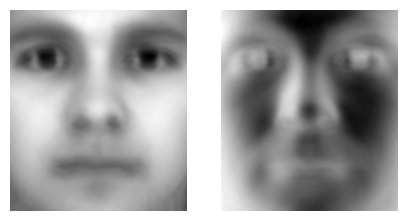

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [5, 5]
plt.rcParams.update({'font.size': 14})

# Extract the necessary data
faces       = mat_contents['faces']
m           = int(np.squeeze(mat_contents['m']))
n           = int(np.squeeze(mat_contents['n']))
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

# We use the first 36 people for training data
trainingFaces = faces[:,:np.sum(nfaces[:36])]

# Average of the training data
avgFace = np.mean(trainingFaces,axis=1) # size n*m by 1

# Compute eigenfaces on mean-subtracted training data
X = trainingFaces - np.tile(avgFace,(trainingFaces.shape[1],1)).T
U, S, VT = np.linalg.svd(X,full_matrices=0)

fig1 = plt.figure()
ax1 = fig1.add_subplot(121)
img_avg = ax1.imshow(np.reshape(avgFace,(m,n)).T)
img_avg.set_cmap('gray')
plt.axis('off')

ax2 = fig1.add_subplot(122)
img_u1 = ax2.imshow(np.reshape(U[:,0],(m,n)).T)
img_u1.set_cmap('gray')
plt.axis('off')

plt.show()

In [ ]:
print("Data Matrix X, shape:",X.shape," size: ", X.size)

Data Matrix X, shape: (32256, 2282)  size:  73608192


In [ ]:
print("U, shape: ", U.shape," size: ", U.size)

U, shape:  (32256, 2282)  size:  73608192


In [ ]:
print("S, shape:",S.shape," size: ", S.size)

S, shape: (2282,)  size:  2282


In [ ]:
print("VT, shape:",VT.shape," size: ", VT.size)

VT, shape: (2282, 2282)  size:  5207524


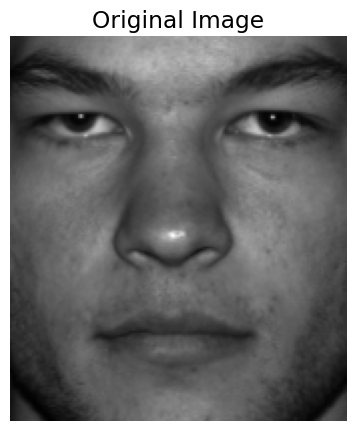

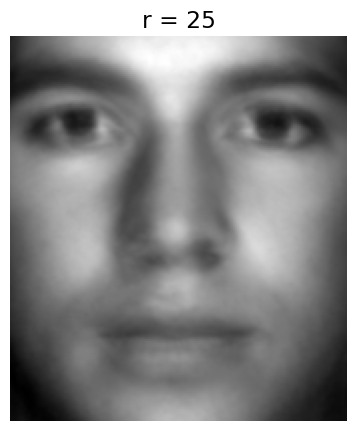

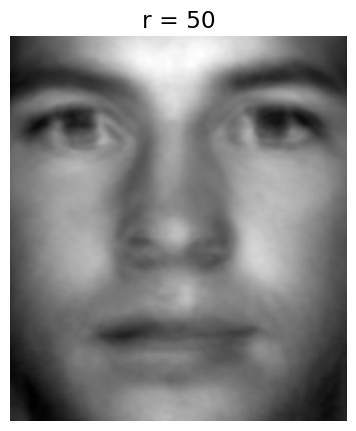

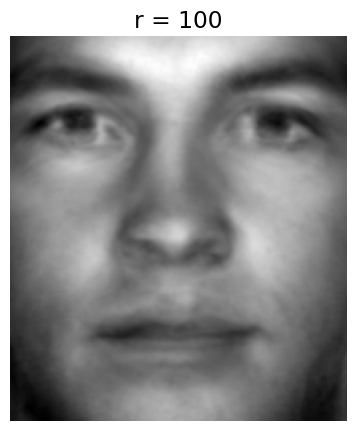

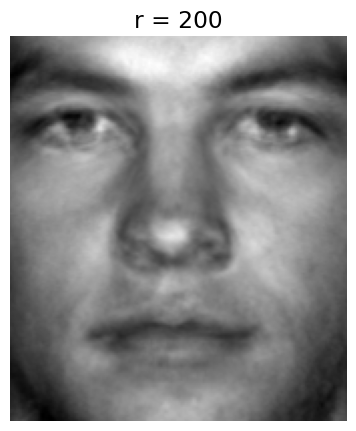

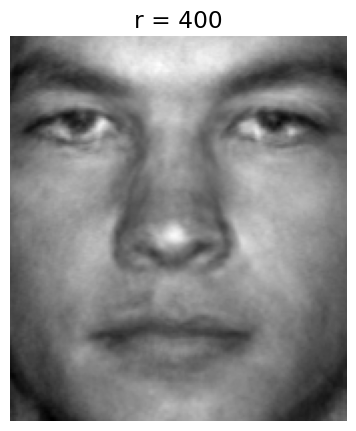

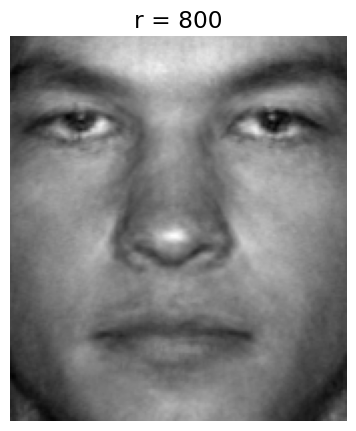

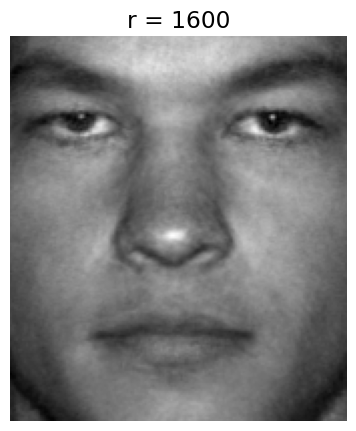

In [ ]:
## Now show eigenface reconstruction of image that was omitted from test set
plt.rcParams['figure.figsize'] = [5, 5]
plt.rcParams.update({'font.size': 14})

testFace = faces[:,np.sum(nfaces[:36])] # First face of person 37
plt.imshow(np.reshape(testFace,(m,n)).T)
plt.set_cmap('gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

testFaceMS = testFace - avgFace
r_list = [25, 50, 100, 200, 400, 800, 1600]
#r_list = [25, 50]

for r in r_list:
    reconFace = avgFace + U[:,:r]  @ U[:,:r].T @ testFaceMS
    img = plt.imshow(np.reshape(reconFace,(m,n)).T)
    img.set_cmap('gray')
    plt.title('r = ' + str(r))
    plt.axis('off')
    plt.show()

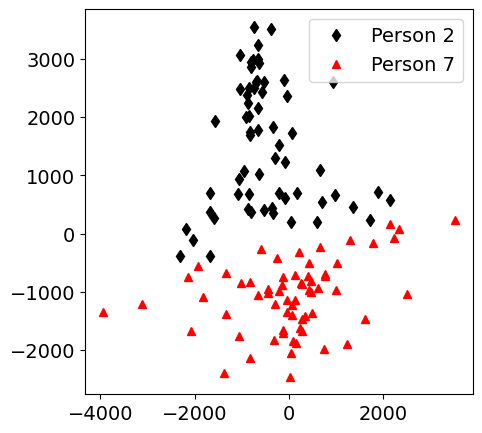

In [ ]:
## Project person 2 and 7 onto PC5 and PC6

P1num = 2 # Person number 2
P2num = 7 # Person number 7

P1 = faces[:,np.sum(nfaces[:(P1num-1)]):np.sum(nfaces[:P1num])]
P2 = faces[:,np.sum(nfaces[:(P2num-1)]):np.sum(nfaces[:P2num])]

P1 = P1 - np.tile(avgFace,(P1.shape[1],1)).T
P2 = P2 - np.tile(avgFace,(P2.shape[1],1)).T

PCAmodes = [5, 6] # Project onto PCA modes 5 and 6
PCACoordsP1 = U[:,PCAmodes-np.ones_like(PCAmodes)].T @ P1
PCACoordsP2 = U[:,PCAmodes-np.ones_like(PCAmodes)].T @ P2

plt.plot(PCACoordsP1[0,:],PCACoordsP1[1,:],'d',color='k',label='Person 2')
plt.plot(PCACoordsP2[0,:],PCACoordsP2[1,:],'^',color='r',label='Person 7')

plt.legend()
plt.show()